# FSA Study Area and Weather Station Coverage Map

This notebook creates a supporting map for the Capstone project using the official
**Statistics Canada 2021 Cartographic Boundary File REST service**.

It retrieves only the six study FSAs: L4T, M5R, M5S, M6G, M9R, and M9W.

Weather stations:
- **Toronto City** — Climate ID 6158355
- **Toronto INTL A** — Climate ID 6158731

FSA polygons are colored according to the weather station assigned in the project.


In [ ]:
# Run this cell only if the required libraries are not installed.
# %pip install geopandas requests matplotlib shapely pyproj


In [1]:
from pathlib import Path
import json
import requests
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


## 1. Study configuration


In [2]:
STUDY_FSAS = ["L4T", "M5R", "M5S", "M6G", "M9R", "M9W"]

STATIONS = pd.DataFrame(
    [
        {
            "station": "Toronto City",
            "climate_id": "6158355",
            "latitude": 43.6667,
            "longitude": -79.4000,
        },
        {
            "station": "Toronto INTL A",
            "climate_id": "6158731",
            "latitude": 43.6767,
            "longitude": -79.6306,
        },
    ]
)

FSA_TO_STATION = {
    "M5S": "Toronto City",
    "M5R": "Toronto City",
    "M6G": "Toronto City",
    "L4T": "Toronto INTL A",
    "M9W": "Toronto INTL A",
    "M9R": "Toronto INTL A",
}

COVERAGE_COLORS = {
    "Toronto City": "#4C78A8",
    "Toronto INTL A": "#F28E2B",
}


## 2. Download the six FSA polygons from Statistics Canada

Official FSA layer:

`https://geo.statcan.gc.ca/geo_wa/rest/services/2021/Cartographic_boundary_files/MapServer/14`

The query below requests only the six FSAs and returns GeoJSON in WGS84 (`EPSG:4326`).


In [3]:
FSA_LAYER_URL = (
    "https://geo.statcan.gc.ca/geo_wa/rest/services/"
    "2021/Cartographic_boundary_files/MapServer/14/query"
)

where_clause = "CFSAUID IN ({})".format(
    ",".join(f"'{fsa}'" for fsa in STUDY_FSAS)
)

params = {
    "where": where_clause,
    "outFields": "CFSAUID,PRUID,PRNAME,LANDAREA",
    "returnGeometry": "true",
    "outSR": "4326",
    "f": "geojson",
}

response = requests.get(
    FSA_LAYER_URL,
    params=params,
    timeout=60,
)
response.raise_for_status()

geojson = response.json()

if "features" not in geojson or len(geojson["features"]) == 0:
    raise RuntimeError("Statistics Canada returned no FSA geometries.")

print("Downloaded features:", len(geojson["features"]))
print("Request URL:")
print(response.url)


Downloaded features: 6
Request URL:
https://geo.statcan.gc.ca/geo_wa/rest/services/2021/Cartographic_boundary_files/MapServer/14/query?where=CFSAUID+IN+%28%27L4T%27%2C%27M5R%27%2C%27M5S%27%2C%27M6G%27%2C%27M9R%27%2C%27M9W%27%29&outFields=CFSAUID%2CPRUID%2CPRNAME%2CLANDAREA&returnGeometry=true&outSR=4326&f=geojson


In [4]:
geojson_path = Path("study_fsas_statcan_2021.geojson")

geojson_path.write_text(
    json.dumps(geojson),
    encoding="utf-8",
)

fsas = gpd.read_file(geojson_path)

fsas["CFSAUID"] = fsas["CFSAUID"].astype(str)
fsas = fsas.loc[fsas["CFSAUID"].isin(STUDY_FSAS)].copy()
fsas["assigned_station"] = fsas["CFSAUID"].map(FSA_TO_STATION)

missing_fsas = sorted(set(STUDY_FSAS) - set(fsas["CFSAUID"]))

if missing_fsas:
    raise RuntimeError(f"Missing FSA geometries: {missing_fsas}")

print("Validation PASS: all 6 study FSAs were retrieved.")
display(
    fsas[
        ["CFSAUID", "assigned_station", "LANDAREA"]
    ].sort_values("CFSAUID")
)


Validation PASS: all 6 study FSAs were retrieved.


,CFSAUID,assigned_station,LANDAREA
0,L4T,Toronto INTL A,33.7566
1,M5R,Toronto City,2.8276
2,M5S,Toronto City,1.8915
3,M6G,Toronto City,3.8615
4,M9R,Toronto INTL A,6.5681
5,M9W,Toronto INTL A,27.3161


## 3. Create station points


In [5]:
stations_gdf = gpd.GeoDataFrame(
    STATIONS.copy(),
    geometry=gpd.points_from_xy(
        STATIONS["longitude"],
        STATIONS["latitude"],
    ),
    crs="EPSG:4326",
)

stations_gdf


,station,climate_id,latitude,longitude,geometry
0,Toronto City,6158355,43.6667,-79.4000,POINT (-79.4 43.6667)
1,Toronto INTL A,6158731,43.6767,-79.6306,POINT (-79.6306 43.6767)


## 4. Create the presentation map


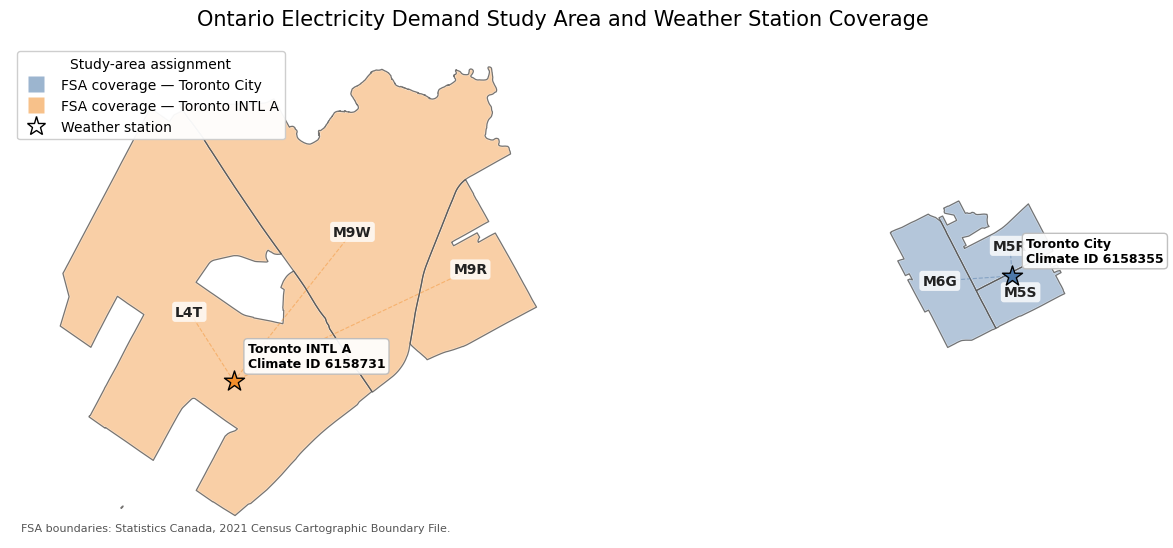

Saved map: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\notebooks\maps\FSA_weather_station_coverage_map.png


In [6]:
# Statistics Canada Lambert projection for cleaner local mapping.
fsas_plot = fsas.to_crs("EPSG:3347")
stations_plot = stations_gdf.to_crs("EPSG:3347")

fig, ax = plt.subplots(figsize=(12, 9))

# FSA polygons by assigned station.
for station_name, color in COVERAGE_COLORS.items():
    subset = fsas_plot.loc[
        fsas_plot["assigned_station"] == station_name
    ]

    subset.plot(
        ax=ax,
        facecolor=color,
        edgecolor="white",
        linewidth=1.8,
        alpha=0.42,
    )

# Outer boundaries.
fsas_plot.boundary.plot(
    ax=ax,
    color="#555555",
    linewidth=0.9,
    alpha=0.8,
)

# FSA labels.
for _, row in fsas_plot.iterrows():
    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        row["CFSAUID"],
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#222222",
        bbox={
            "boxstyle": "round,pad=0.22",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.78,
        },
        zorder=5,
    )

# Station markers.
for _, station in stations_plot.iterrows():
    color = COVERAGE_COLORS[station["station"]]

    ax.scatter(
        station.geometry.x,
        station.geometry.y,
        s=230,
        marker="*",
        color=color,
        edgecolor="black",
        linewidth=1.0,
        zorder=8,
    )

    ax.annotate(
        f'{station["station"]}\nClimate ID {station["climate_id"]}',
        xy=(station.geometry.x, station.geometry.y),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "edgecolor": "#BBBBBB",
            "alpha": 0.92,
        },
        zorder=9,
    )

# Thin connection lines from station to assigned FSA.
station_lookup = {
    row["station"]: row.geometry
    for _, row in stations_plot.iterrows()
}

for _, row in fsas_plot.iterrows():
    fsa_point = row.geometry.representative_point()
    station_point = station_lookup[row["assigned_station"]]

    ax.plot(
        [station_point.x, fsa_point.x],
        [station_point.y, fsa_point.y],
        color=COVERAGE_COLORS[row["assigned_station"]],
        linewidth=0.8,
        linestyle="--",
        alpha=0.45,
        zorder=2,
    )

legend_items = [
    Line2D(
        [0], [0],
        marker="s",
        color="none",
        markerfacecolor=COVERAGE_COLORS["Toronto City"],
        markeredgecolor="none",
        markersize=12,
        alpha=0.55,
        label="FSA coverage — Toronto City",
    ),
    Line2D(
        [0], [0],
        marker="s",
        color="none",
        markerfacecolor=COVERAGE_COLORS["Toronto INTL A"],
        markeredgecolor="none",
        markersize=12,
        alpha=0.55,
        label="FSA coverage — Toronto INTL A",
    ),
    Line2D(
        [0], [0],
        marker="*",
        color="black",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=14,
        linestyle="None",
        label="Weather station",
    ),
]

ax.legend(
    handles=legend_items,
    loc="upper left",
    frameon=True,
    framealpha=0.95,
    title="Study-area assignment",
)

ax.set_title(
    "Ontario Electricity Demand Study Area and Weather Station Coverage",
    fontsize=15,
    pad=14,
)

ax.set_axis_off()

ax.text(
    0.01,
    0.01,
    "FSA boundaries: Statistics Canada, 2021 Census Cartographic Boundary File.",
    transform=ax.transAxes,
    fontsize=8,
    color="#555555",
    ha="left",
    va="bottom",
)

fig.tight_layout()

OUTPUT_PNG = Path("FSA_weather_station_coverage_map.png")

fig.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Saved map: {OUTPUT_PNG.resolve()}")


## 5. Save the six FSA polygons for reuse

This avoids calling the API again if the same geometry is needed later.


In [ ]:
OUTPUT_GEOJSON = Path("study_fsas_statcan_2021_selected.geojson")

fsas.to_file(
    OUTPUT_GEOJSON,
    driver="GeoJSON",
)

print(f"Saved GeoJSON: {OUTPUT_GEOJSON.resolve()}")


In [7]:
from generate_toronto_fsa_station_map import create_map
from pathlib import Path

In [8]:
create_map(
    Path("map_outputs/Toronto_FSA_Weather_Stations_Presentation_Map.png")
)

HTTPError: 500 Server Error: Internal Server Error for url: https://geo.statcan.gc.ca/geo_wa/rest/services/2021/Cartographic_boundary_files/MapServer/14/query?where=PRUID+%3D+%2735%27&outFields=CFSAUID%2CPRUID%2CPRNAME%2CLANDAREA&returnGeometry=true&outSR=4326&f=geojson